<a href="https://colab.research.google.com/github/PiyumalRathnayake/Treinetic_ImageClassification/blob/main/TreineticV1V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **METHOD 1**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

### 1. Data Preparation & Preprocessing

In [ ]:
print("Loading and preprocessing dataset...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

Loading and preprocessing dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


### 2. Model Development & Improvement

In [ ]:
# Applying data augmentation as the required "Improvement" technique
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# Building the CNN Architecture
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    # Convolutional layers to extract spatial features
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Flatten(),

    # Dense layers for classification
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Dropout to prevent overfitting
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### 3. Training

In [ ]:
print("Training the model...")
# Training for 15 epochs
history = model.fit(train_images, train_labels, epochs=15,
                    validation_data=(test_images, test_labels))

Training the model...
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 91ms/step - accuracy: 0.3602 - loss: 1.7490 - val_accuracy: 0.4844 - val_loss: 1.4473
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.4763 - loss: 1.4621 - val_accuracy: 0.5733 - val_loss: 1.1883
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.5241 - loss: 1.3407 - val_accuracy: 0.5835 - val_loss: 1.1686
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 90ms/step - accuracy: 0.5559 - loss: 1.2547 - val_accuracy: 0.6353 - val_loss: 1.0497
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 89ms/step - accuracy: 0.5765 - loss: 1.2061 - val_accuracy: 0.6474 - val_loss: 1.0108
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 89ms/step - accuracy: 0.5942 - loss: 1.1567 - val_accuracy: 0.6586 - val_loss: 0.9774
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 87ms/step - accuracy: 0.6087 - loss: 1.1255 - val_accuracy: 0.6816 - val_loss: 0.9242
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 

### 4. Evaluation & Results Visualization

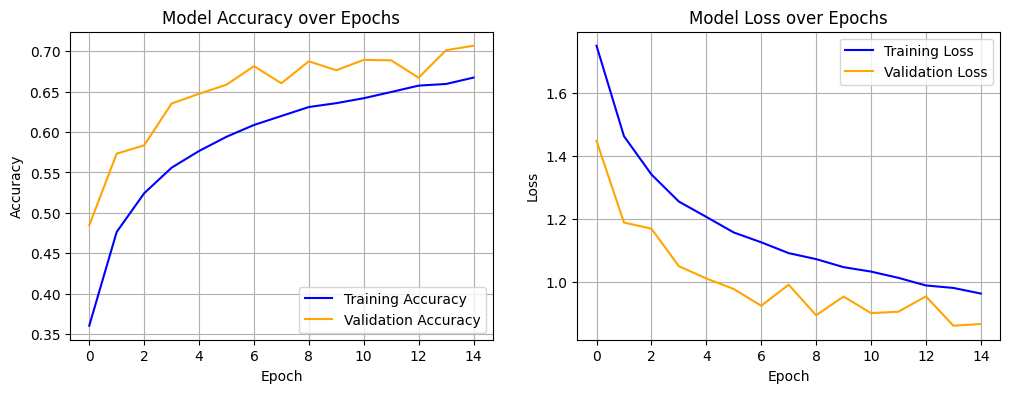


Evaluating on test data...
Overall Test Accuracy: 0.7069

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step
Detailed Classification Report:
              precision    recall  f1-score   support

    airplane       0.68      0.81      0.74      1000
  automobile       0.82      0.82      0.82      1000
        bird       0.66      0.59      0.62      1000
         cat       0.61      0.47      0.53      1000
        deer       0.76      0.53      0.62      1000
         dog       0.72      0.55      0.62      1000
        frog       0.67      0.85      0.75      1000
       horse       0.69      0.82      0.75      1000
        ship       0.88      0.76      0.82      1000
       truck       0.64      0.87      0.74      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.70     10000
weighted avg       0.71      0.71      0.70     10000



In [ ]:
# Plotting Accuracy and Loss Graphs
plt.figure(figsize=(12, 4))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

# Generating Metrics (Accuracy, Precision, Recall, F1-Score)
print("\nEvaluating on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Overall Test Accuracy: {test_acc:.4f}\n")

# Get predictions to calculate precision and recall
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

print("Detailed Classification Report:")
print(classification_report(test_labels, predicted_classes, target_names=class_names))

### Continue Training from Epoch 16 to 30

In [ ]:
# ==========================================
# Continue Training from Epoch 16 to 30
# ==========================================
print("Continuing training for 15 more epochs (Total 30)...")

# The model already has the weights from the first 15 epochs.
# We use initial_epoch=15 so it starts counting at 16.
history_continued = model.fit(train_images, train_labels,
                              epochs=30,             # The new total number of epochs
                              initial_epoch=15,      # Tell it we already did 15
                              validation_data=(test_images, test_labels))

Continuing training for 15 more epochs (Total 30)...
Epoch 16/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.6728 - loss: 0.9493 - val_accuracy: 0.7190 - val_loss: 0.8229
Epoch 17/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 89ms/step - accuracy: 0.6736 - loss: 0.9473 - val_accuracy: 0.7186 - val_loss: 0.8164
Epoch 18/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 89ms/step - accuracy: 0.6749 - loss: 0.9414 - val_accuracy: 0.6912 - val_loss: 0.9040
Epoch 19/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.6837 - loss: 0.9168 - val_accuracy: 0.7097 - val_loss: 0.8457
Epoch 20/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 92ms/step - accuracy: 0.6890 - loss: 0.9101 - val_accuracy: 0.7007 - val_loss: 0.8882
Epoch 21/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.6882 - loss: 0.9143 - val_accuracy: 0.7147 - val_loss: 0.8275
Epoch 22/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 87ms/step - accuracy: 0.6870 - loss: 0.8994 - val_accuracy: 0.7063 - val_loss: 0.8996
Epoch 23/

### Merge Histories and Update the Graphs

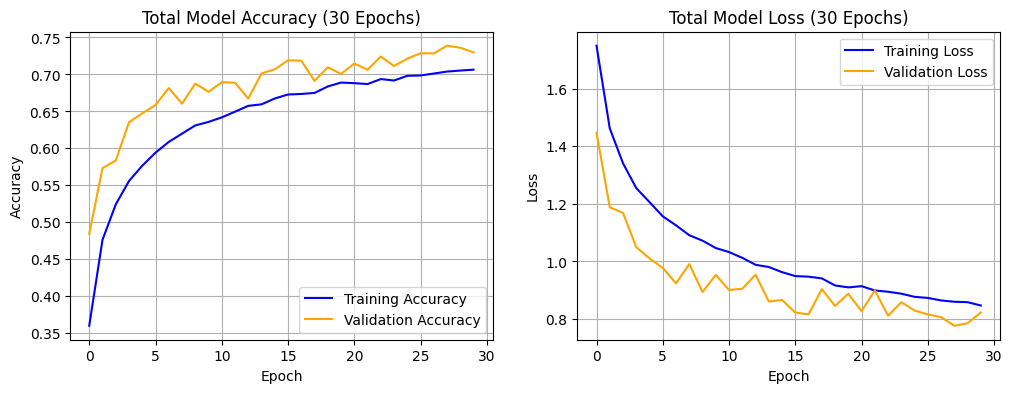

In [ ]:
# This combines the old history with the new history for a complete plot
for key in history.history.keys():
    history.history[key].extend(history_continued.history[key])

# Re-run your plotting code to see the full 30-epoch trend
plt.figure(figsize=(12, 4))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Total Model Accuracy (30 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Total Model Loss (30 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

### 5. Testing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

print("Please upload an image (e.g., a dog, car, bird, etc.):")
# 1. This creates the upload button in Colab
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Load the image and resize it to 32x32 pixels (what CIFAR-10 expects)
    img_path = filename
    img = image.load_img(img_path, target_size=(32, 32))

    # 3. Convert the image to an array and normalize it (0 to 1)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0

    # 4. Expand dimensions to match the batch format the model expects: (1, 32, 32, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # 5. Make the prediction
    predictions = model.predict(img_batch)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence_score = np.max(predictions[0]) * 100

    # 6. Display the original uploaded image with the result
    # Load original size for better viewing
    original_img = image.load_img(img_path)
    plt.imshow(original_img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class_name} ({confidence_score:.2f}% confidence)")
    plt.show()

Please upload an image (e.g., a dog, car, bird, etc.):


# METHOD 2 - **Deeper CNN with Progressive Dropout**

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Building the Deeper Custom CNN...")

# We will reuse the data augmentation from earlier
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])



Building the Deeper Custom CNN...


### Building a Deeper Architecture

In [5]:
deep_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    # Block 1: Extract basic features (edges, colors)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # 25% dropout to prevent early overfitting

    # Block 2: Extract more complex shapes
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3: Extract high-level object parts
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    # Dense classification head
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # 50% heavy dropout before final decision
    layers.Dense(10, activation='softmax')
])

deep_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Training

In [ ]:
print("Training the deeper model from scratch for 30 epochs...")

# verbose=1 is the setting that creates that exact progress bar output
deep_history = deep_model.fit(
    train_images,
    train_labels,
    epochs=30,
    validation_data=(test_images, test_labels),
    verbose=1
)

Training the deeper model from scratch for 30 epochs...
Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 373s 238ms/step - accuracy: 0.3446 - loss: 1.7777 - val_accuracy: 0.4660 - val_loss: 1.4819
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 372s 238ms/step - accuracy: 0.4514 - loss: 1.5148 - val_accuracy: 0.5261 - val_loss: 1.3033
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 366s 234ms/step - accuracy: 0.4988 - loss: 1.3966 - val_accuracy: 0.5373 - val_loss: 1.2865
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 386s 237ms/step - accuracy: 0.5290 - loss: 1.3165 - val_accuracy: 0.5679 - val_loss: 1.1841
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 369s 236ms/step - accuracy: 0.5463 - loss: 1.2738 - val_accuracy: 0.6143 - val_loss: 1.0922
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 367s 235ms/step - accuracy: 0.5622 - loss: 1.2312 - val_accuracy: 0.6202 - val_loss: 1.0749
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 365s 233ms/step - accuracy: 0.5759 - loss: 1.2030 - val_accuracy: 0.6460 - val_loss: 0.9900
Epoch 

### Visualize the Results

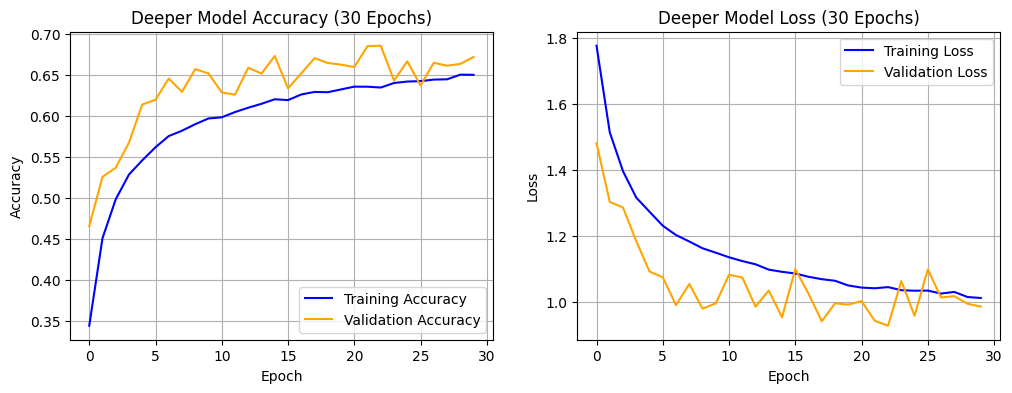

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(deep_history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(deep_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Deeper Model Accuracy (30 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(deep_history.history['loss'], label='Training Loss', color='blue')
plt.plot(deep_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Deeper Model Loss (30 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()



### Testing

In [ ]:
# Final Test Evaluation
deep_test_loss, deep_test_acc = deep_model.evaluate(test_images, test_labels, verbose=0)
print(f"\nFinal Deeper Model Test Accuracy: {deep_test_acc:.4f}")


Final Deeper Model Test Accuracy: 0.6723


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

print("Please upload an image (e.g., a dog, car, bird, etc.):")
# 1. This creates the upload button in Colab
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Load the image and resize it to 32x32 pixels (what CIFAR-10 expects)
    img_path = filename
    img = image.load_img(img_path, target_size=(32, 32))

    # 3. Convert the image to an array and normalize it (0 to 1)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0

    # 4. Expand dimensions to match the batch format the model expects: (1, 32, 32, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # 5. Make the prediction
    predictions = model.predict(img_batch)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence_score = np.max(predictions[0]) * 100

    # 6. Display the original uploaded image with the result
    # Load original size for better viewing
    original_img = image.load_img(img_path)
    plt.imshow(original_img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class_name} ({confidence_score:.2f}% confidence)")
    plt.show()